In [43]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")
import importlib
import itertools
import ipywidgets as widgets

In [44]:
import grafici as gf
importlib.reload(gf)
gf.imposta_stile_globale()

### Raccolta Dati


In [45]:
input_files = ["Ispector_65_Spectrum_1h10m.csv", "Ispector_65_Spectrum_2h.csv", "Ispector_65_Spectrum_3h17m.csv", "Ispector_65_Spectrum_6h20m.csv",
              "Ispector_65_Spectrum_14h03m.csv", "Ispector_65_Spectrum_background.csv", "Ispector_65_Spectrum_carnotite.csv"]
output_files = []
input_paths = []
output_paths = []
bin = 10

In [46]:
for input_file in input_files:
     output_file = input_file.replace('.csv', '.txt')
     output_files.append(output_file)
     input_path = "./Raw/" + input_file
     input_paths.append(input_path)
     output_path = "./Data/" + output_file
     output_paths.append(output_path)

     try:
          subprocess.run(['./RawToData.exe', '-in', input_path, '-out', output_path, '-rebin', str(bin)], stdout=subprocess.DEVNULL, check=True)
          print(f"{input_file:<40} convertito con successo")
     except subprocess.CalledProcessError as e:
          print(f"Errore durante l'esecuzione: {e}")

Ispector_65_Spectrum_1h10m.csv           convertito con successo
Ispector_65_Spectrum_2h.csv              convertito con successo
Ispector_65_Spectrum_3h17m.csv           convertito con successo
Ispector_65_Spectrum_6h20m.csv           convertito con successo
Ispector_65_Spectrum_14h03m.csv          convertito con successo
Ispector_65_Spectrum_background.csv      convertito con successo
Ispector_65_Spectrum_carnotite.csv       convertito con successo


### Istogrammi

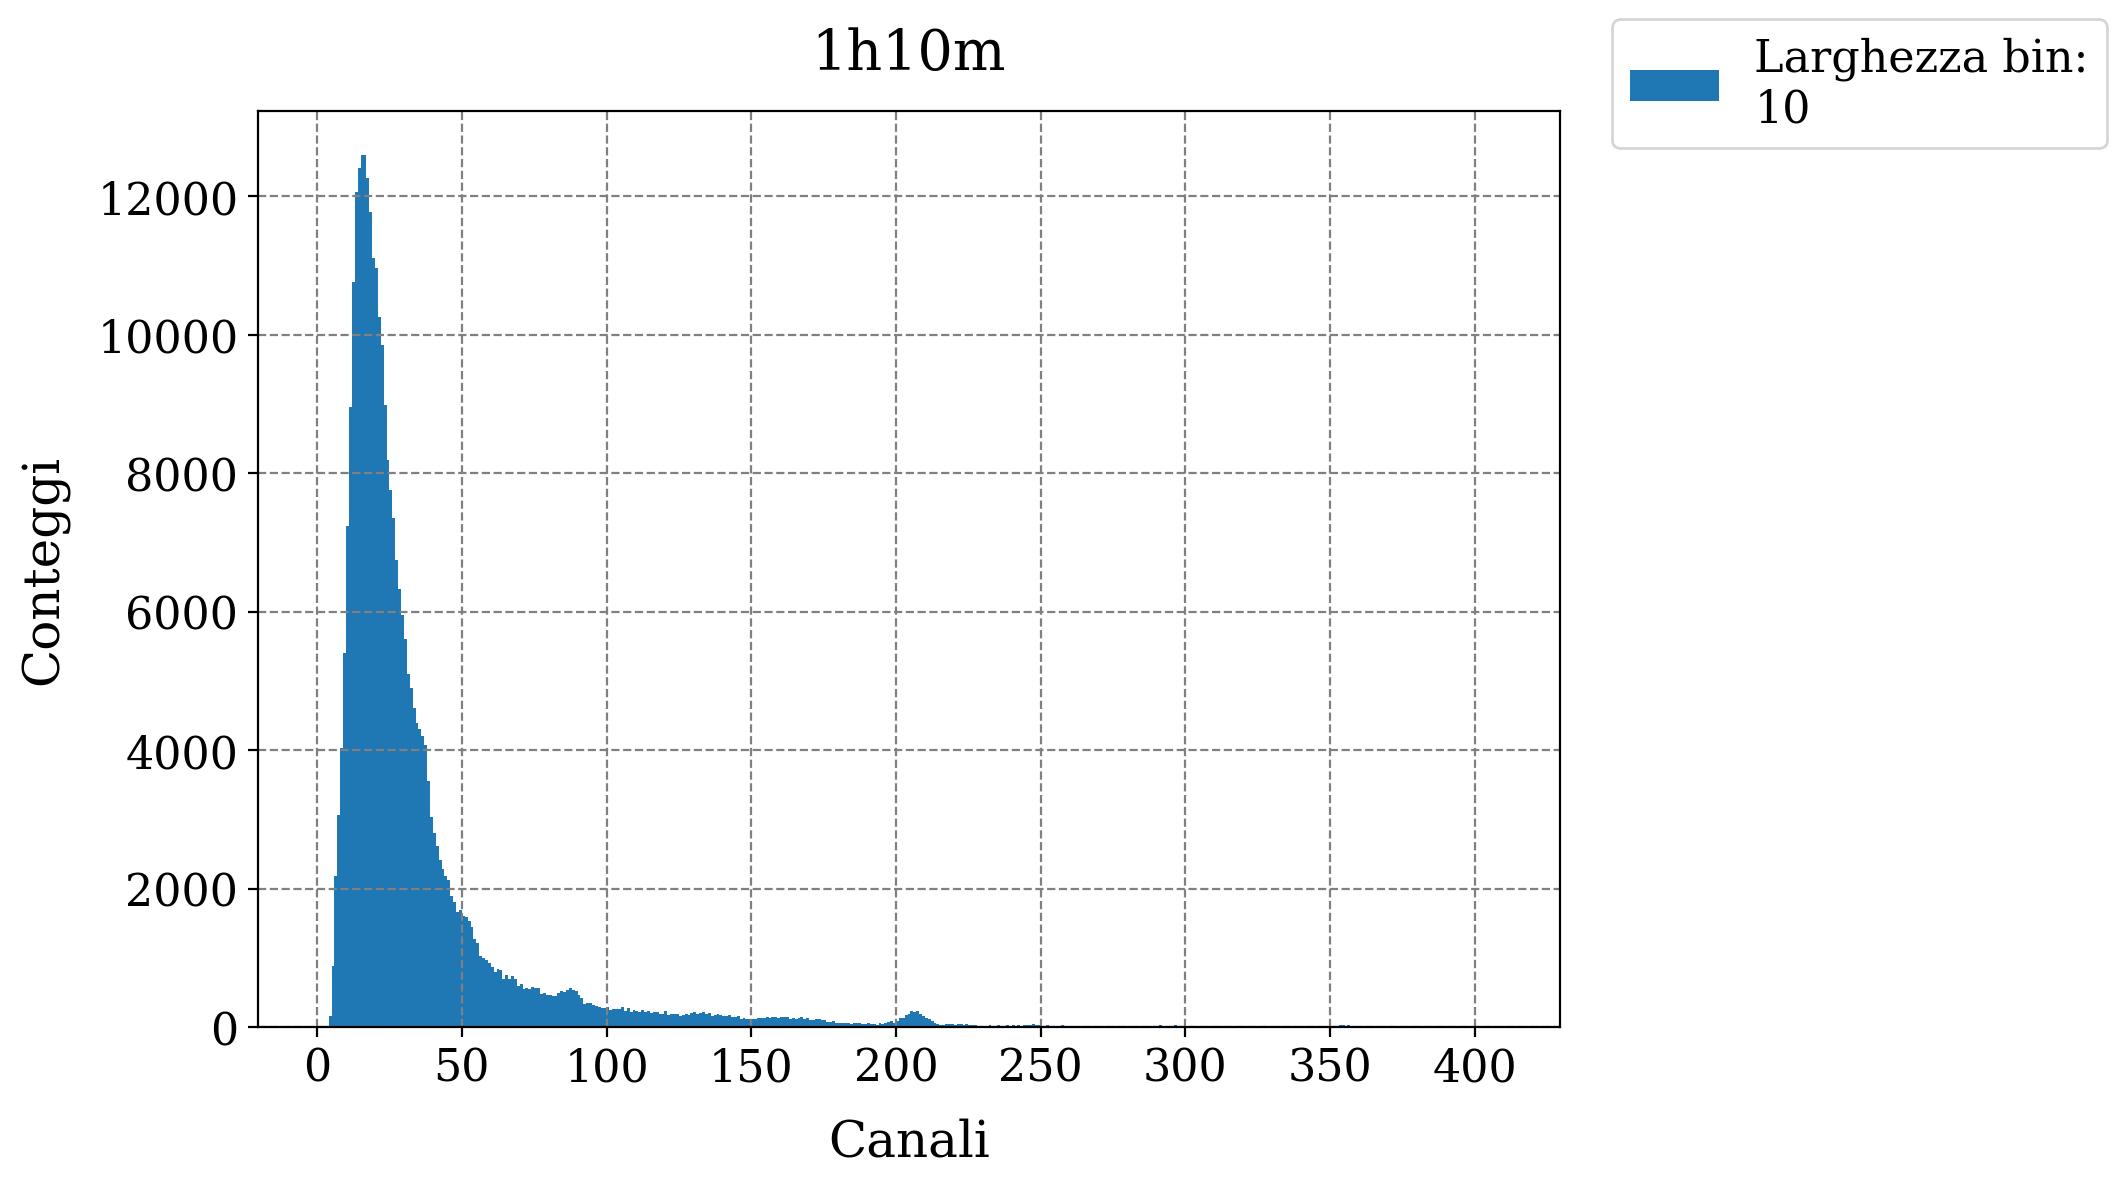

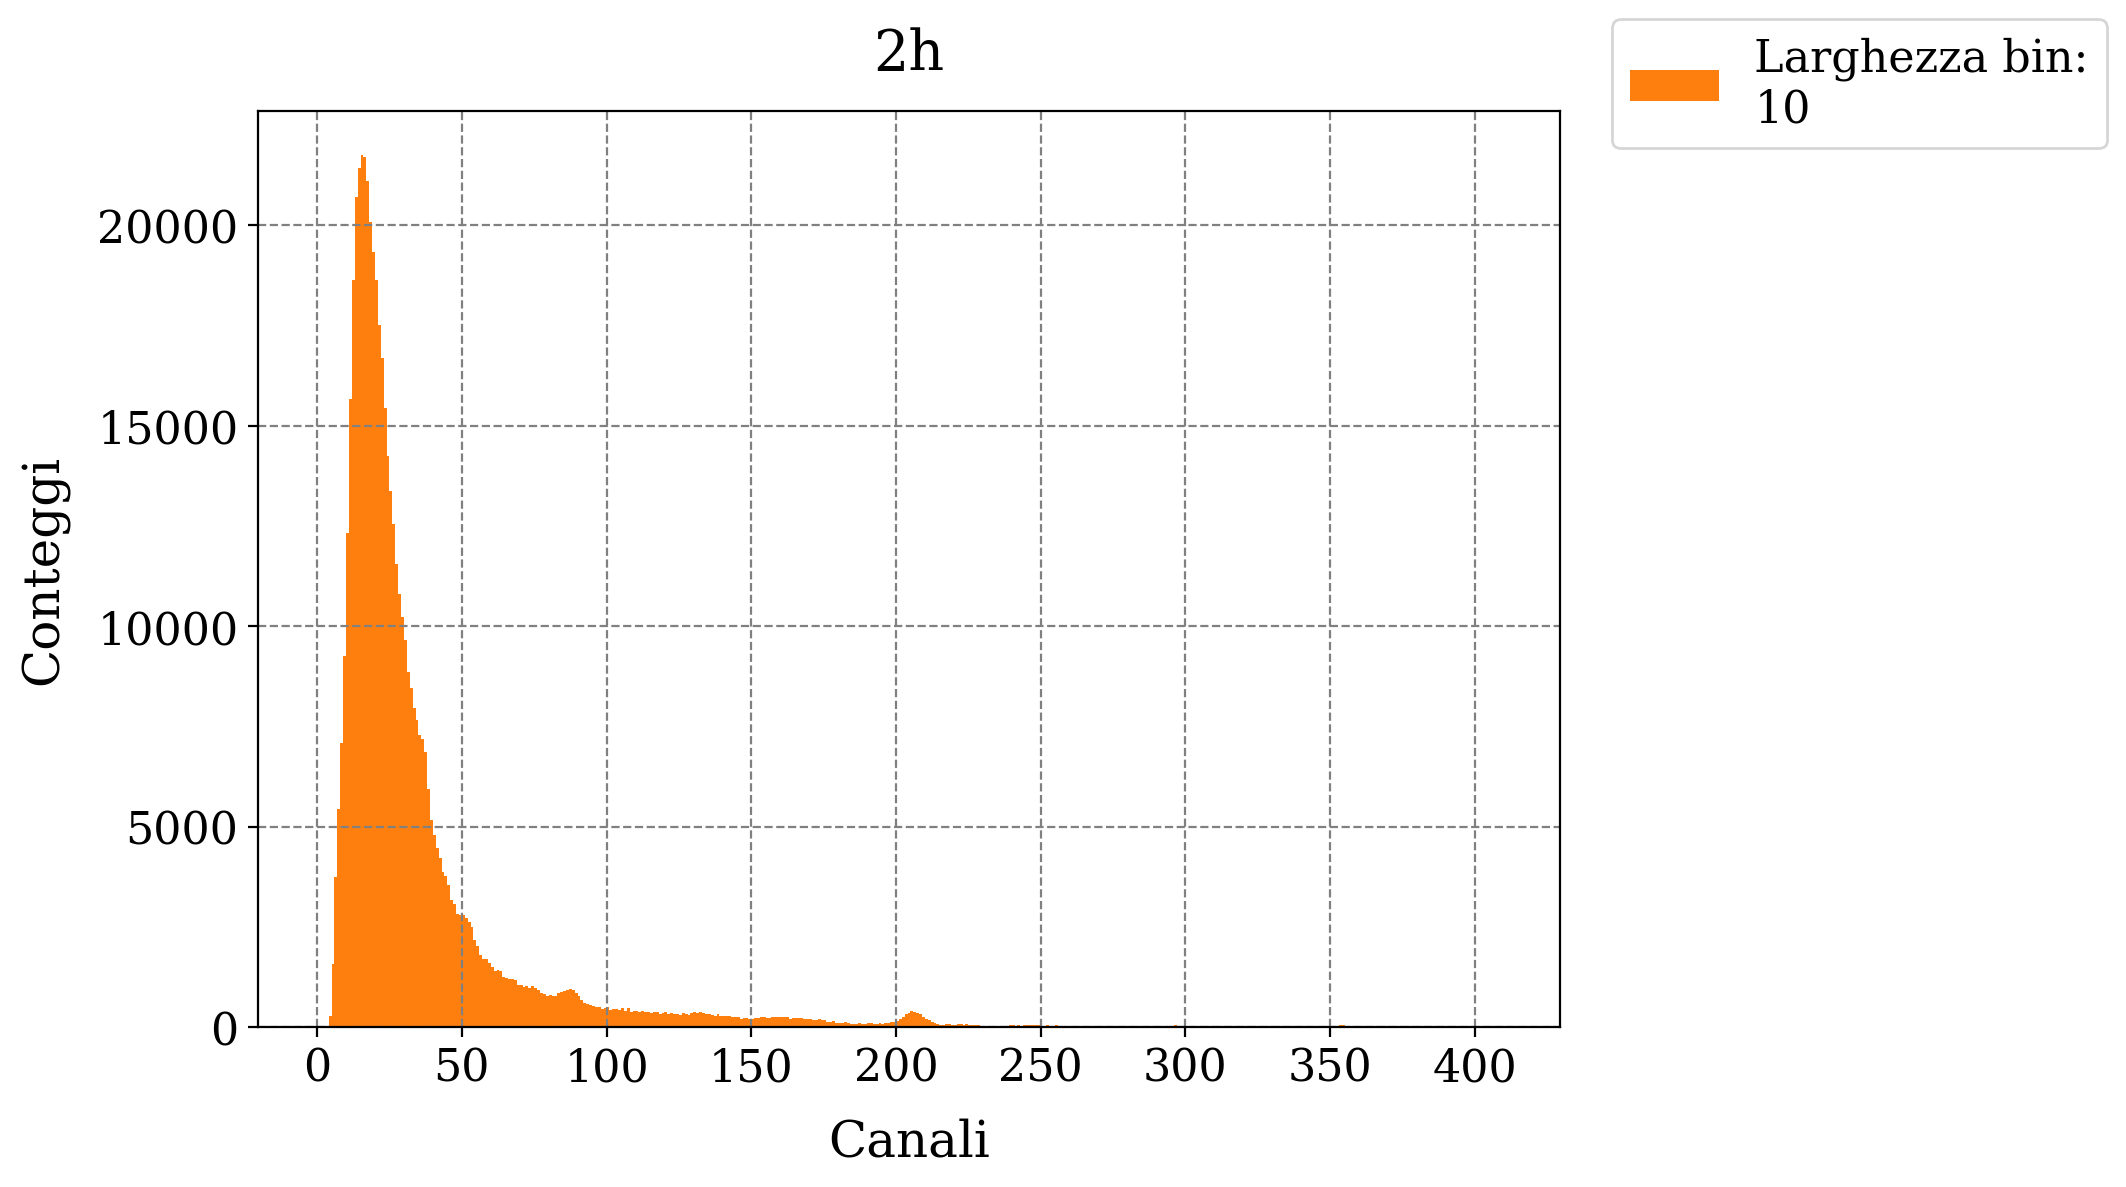

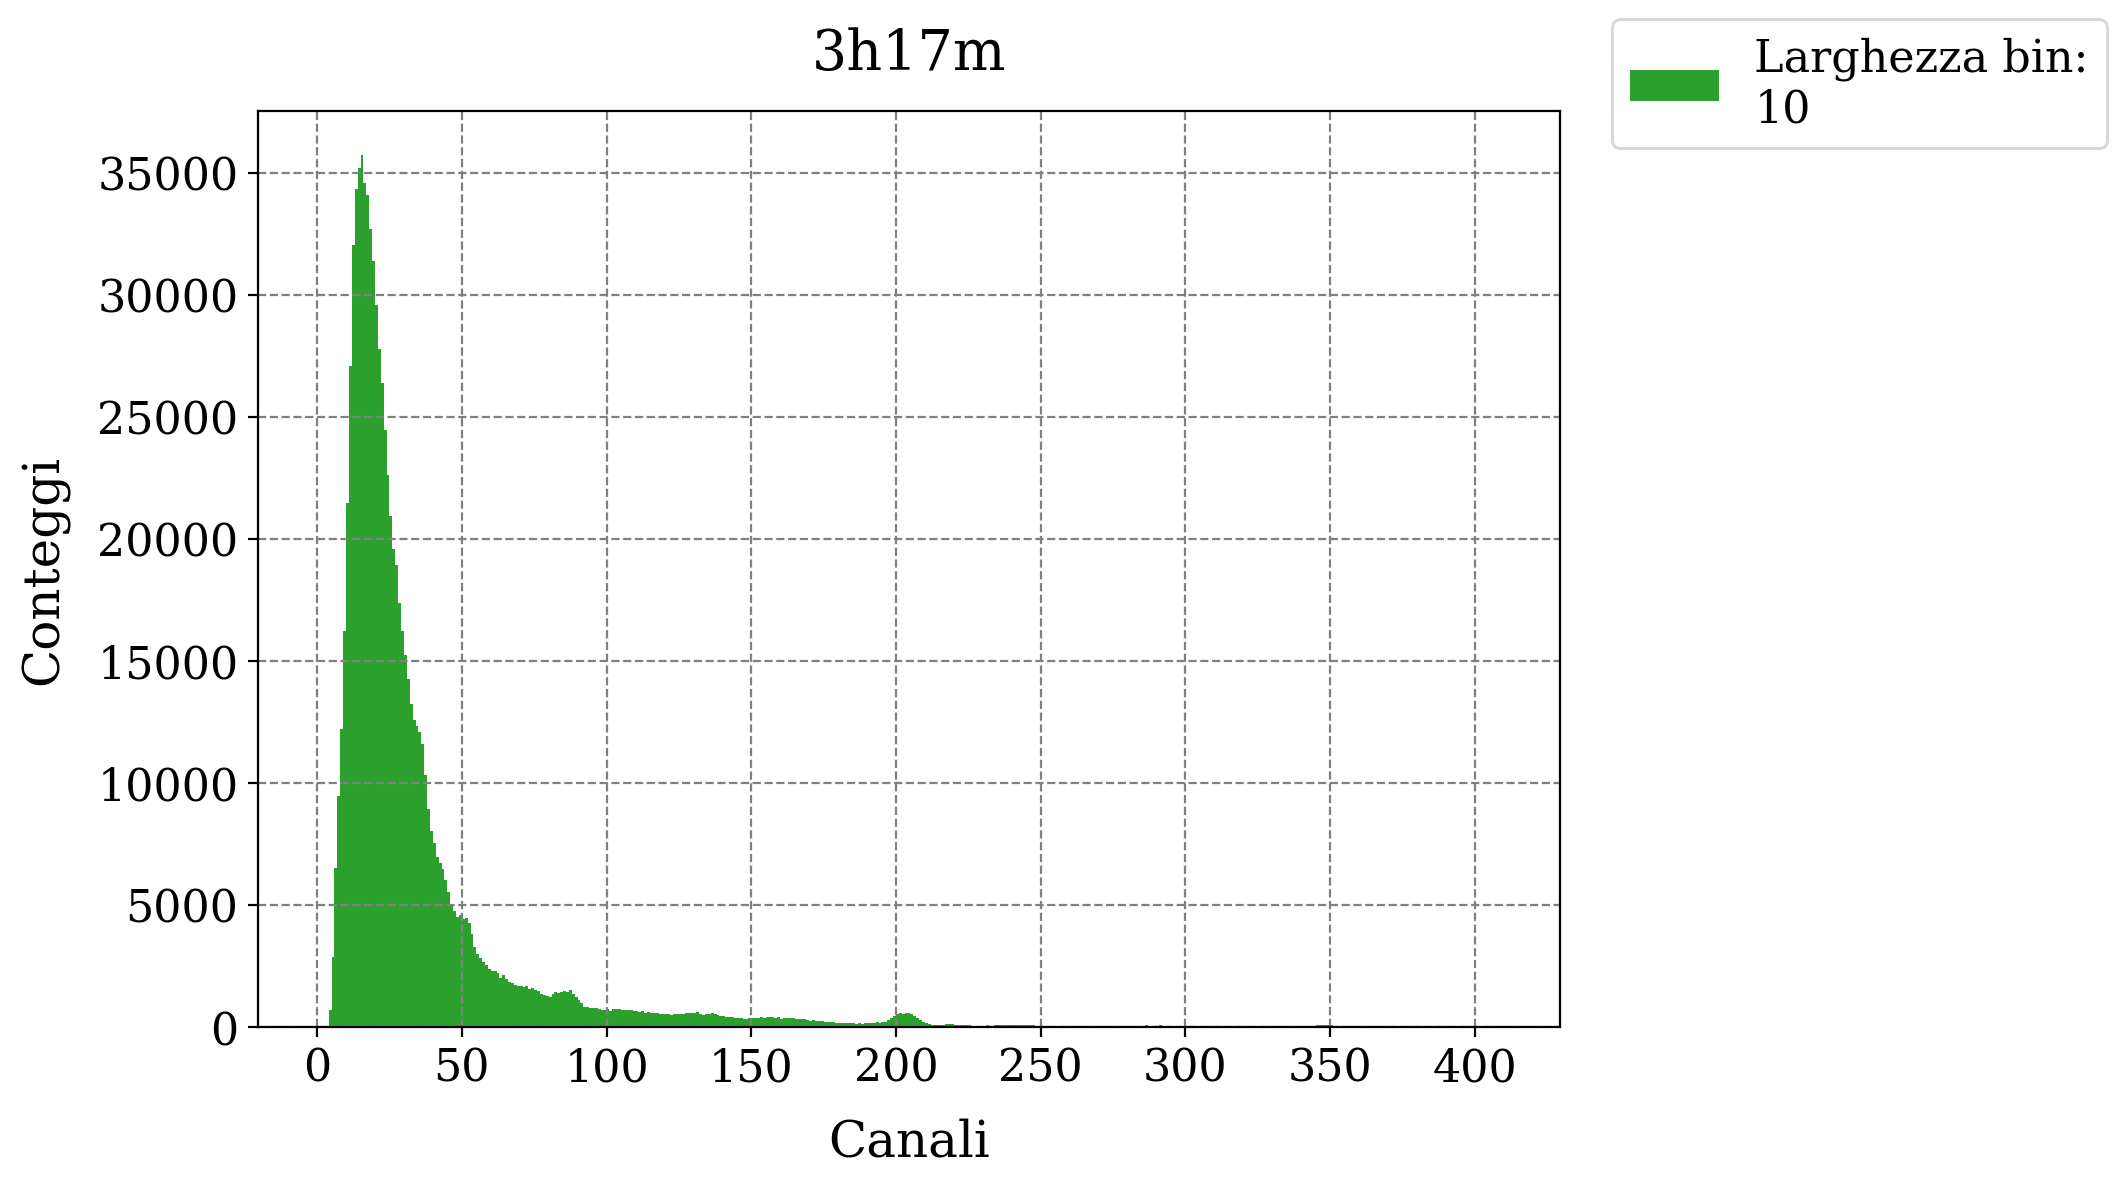

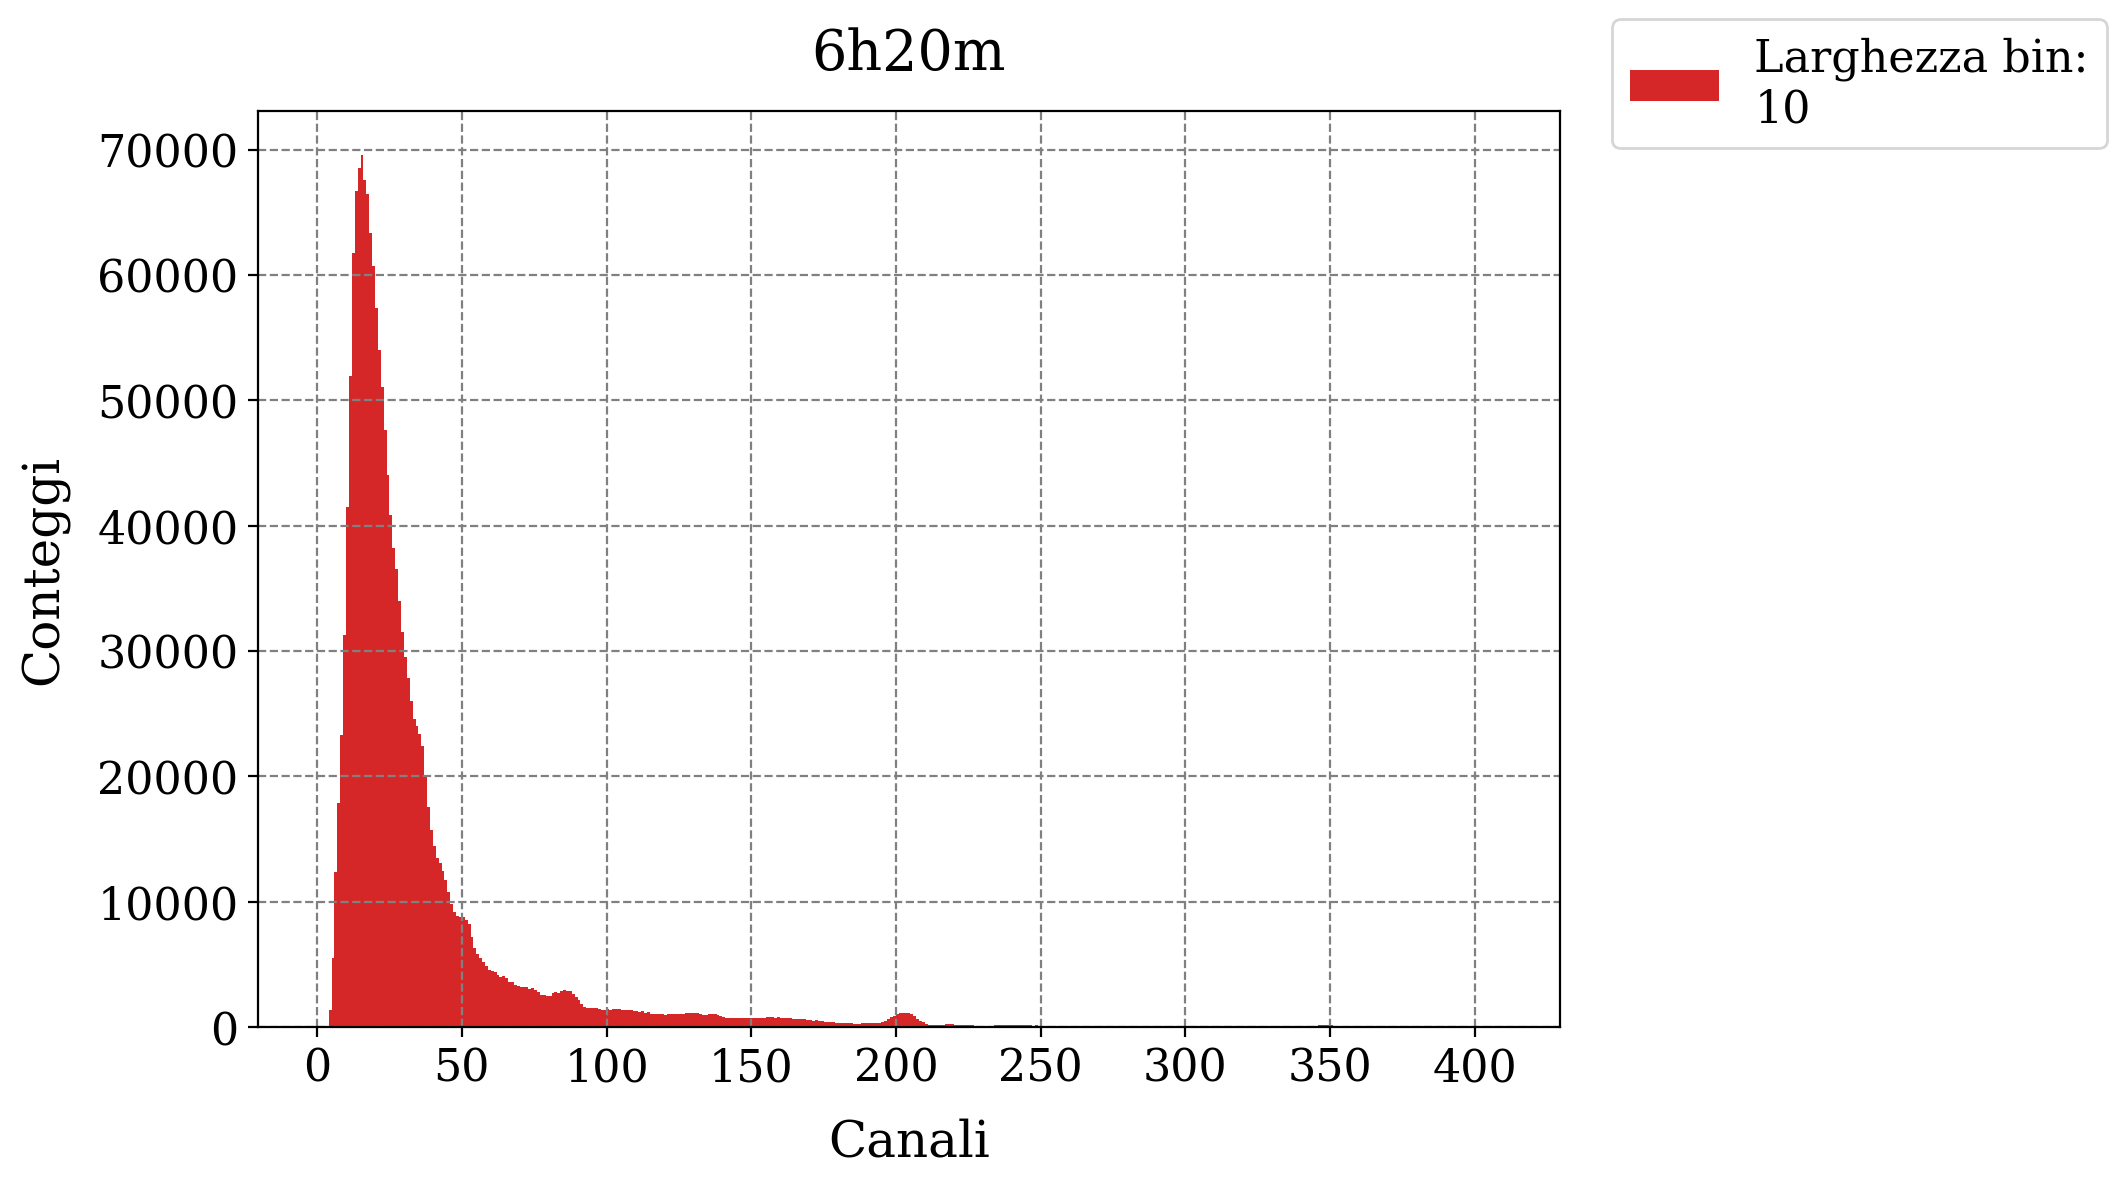

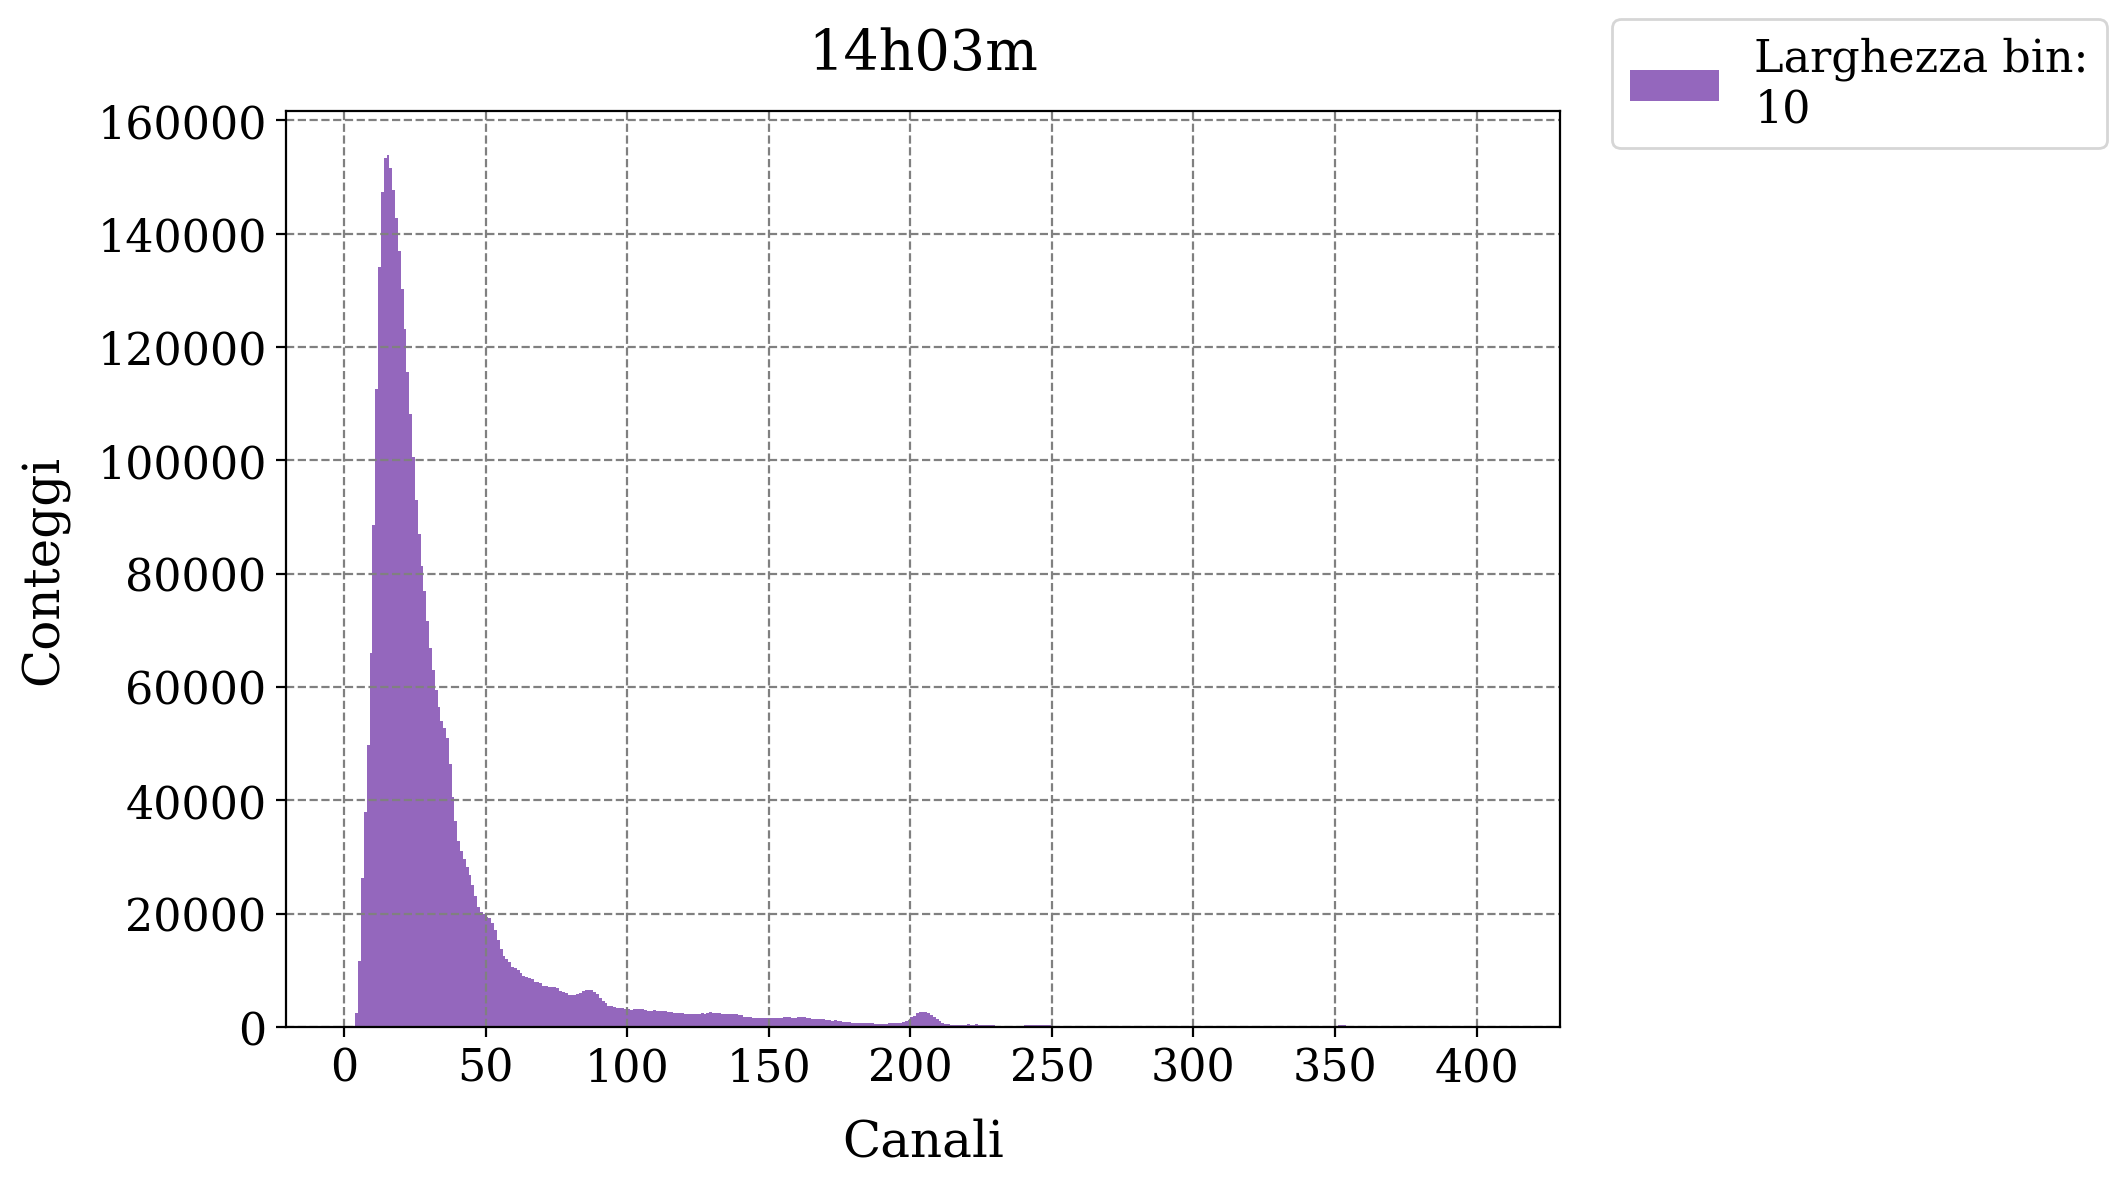

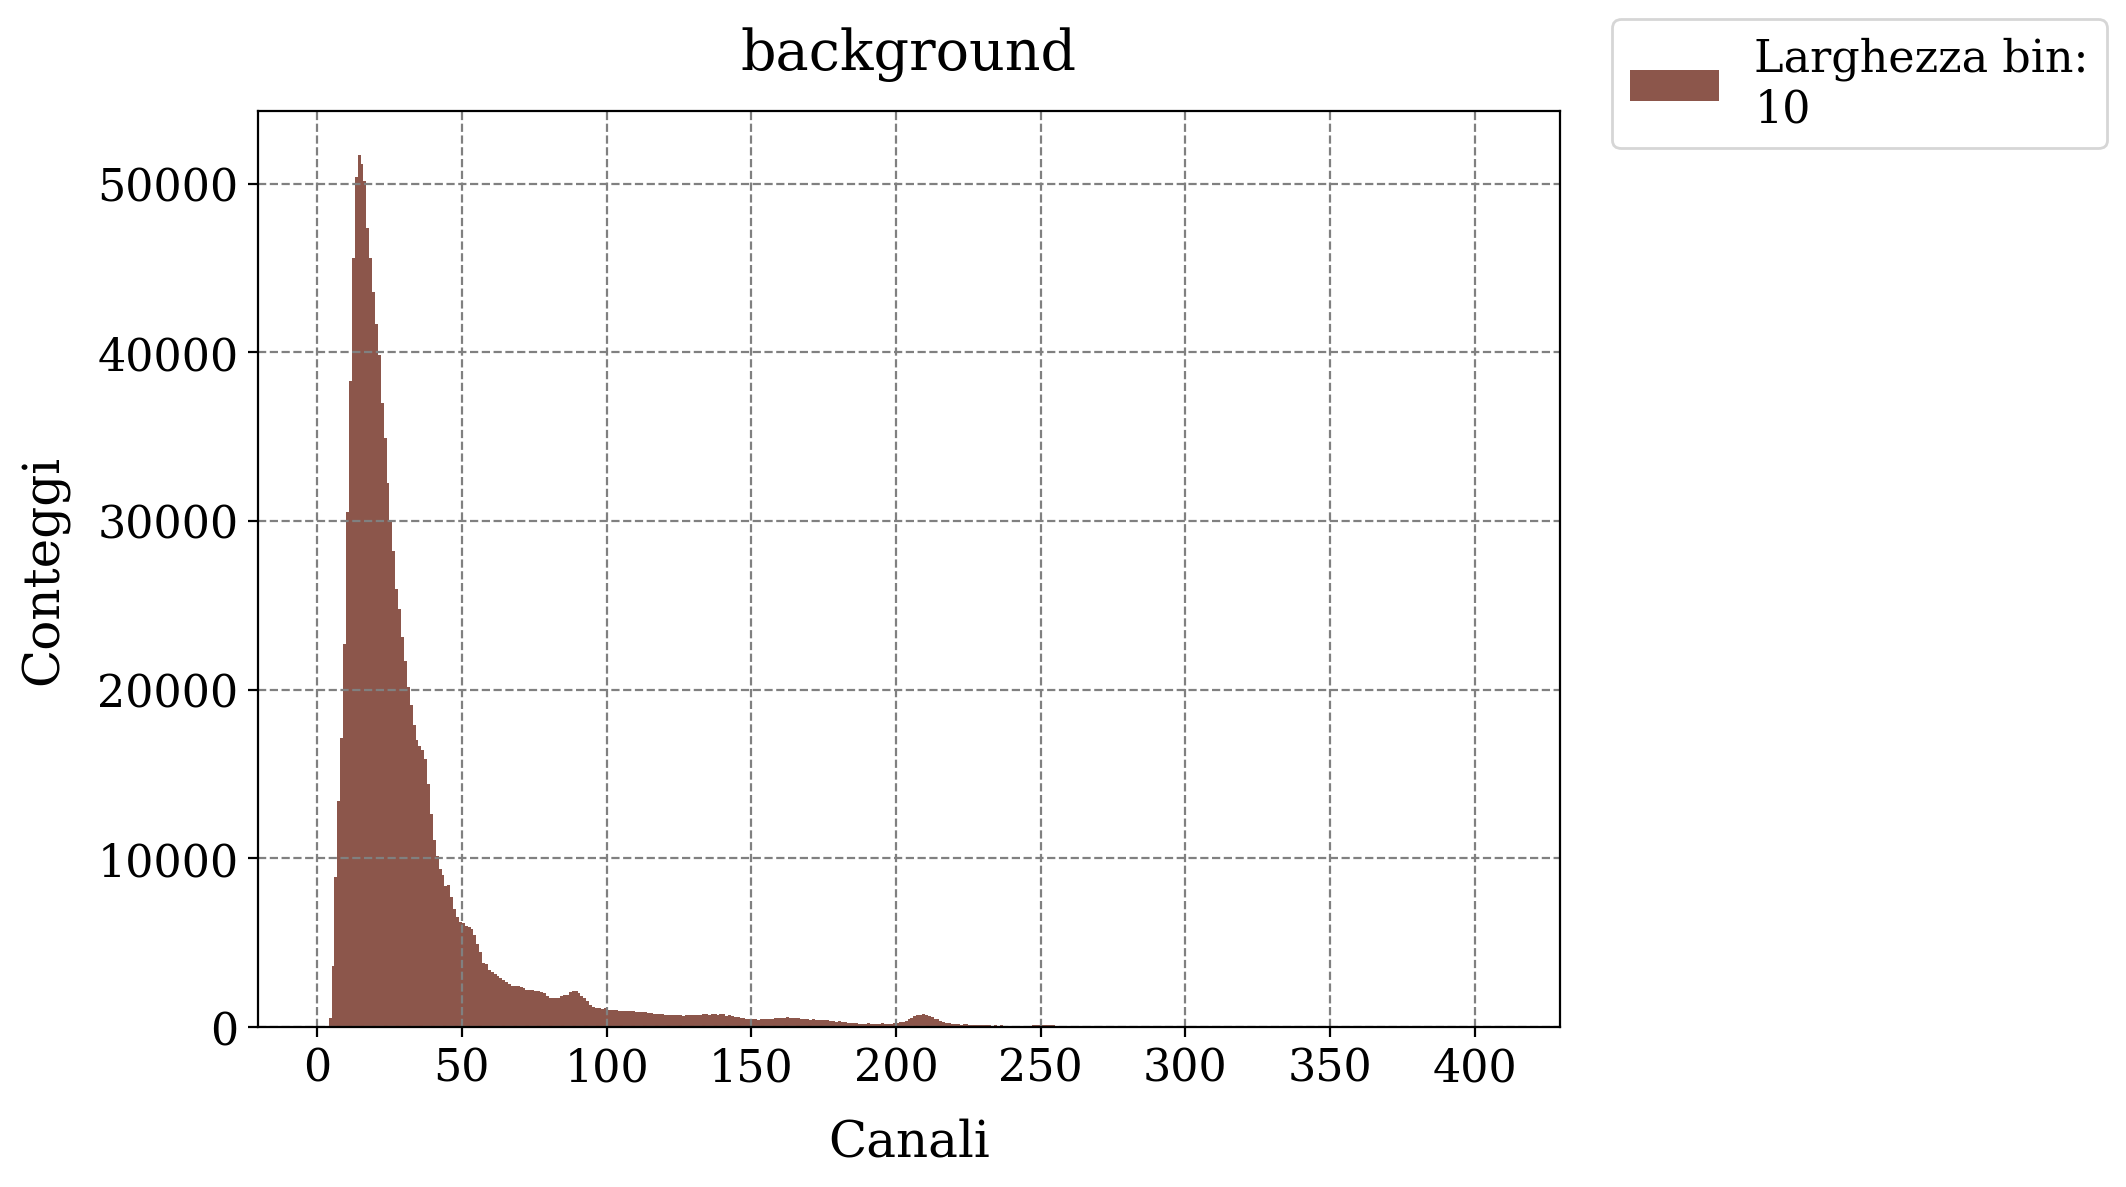

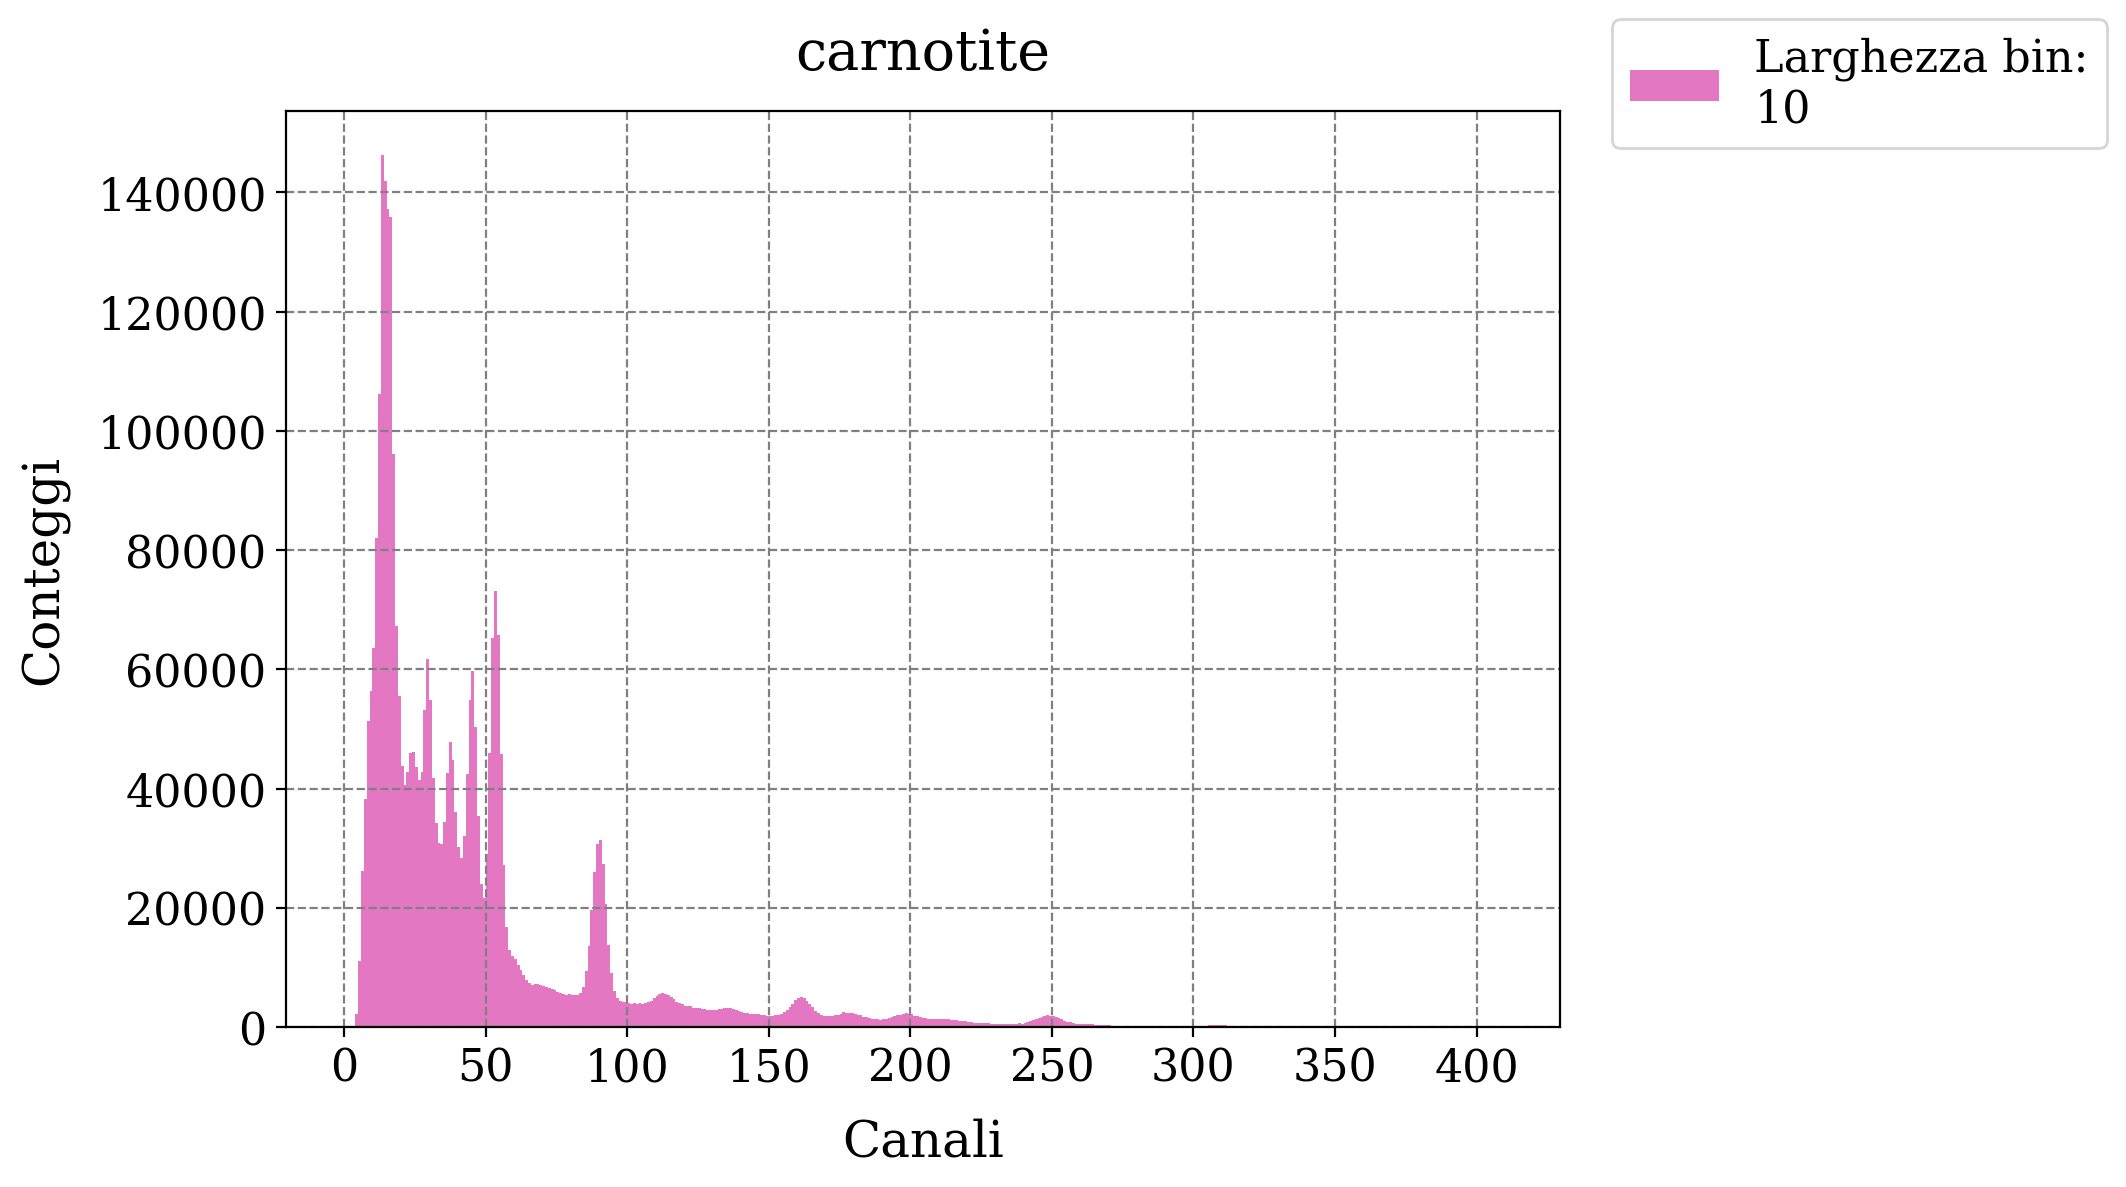

In [52]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
color_cycle = itertools.cycle(colors)

fig_tot, ax_tot = plt.subplots()
alpha = 1.0
for i in range(len(output_files)):
    alpha = alpha - 0.1

    file = output_files[i]
    dati = np.loadtxt(output_paths[i])
    titolo = file.replace("Ispector_65_Spectrum_","").replace(".txt","")

    centri = dati[:,0]
    contenuti = dati[:,1]
    larghezza_bin = centri[1] - centri[0]

    fig, ax = plt.subplots()
    color=next(color_cycle)
    ax.bar(centri, contenuti, width=larghezza_bin, color=color, label=f"Larghezza bin:\n{bin}")
    gf.parametri_grafico(ax, titolo=titolo, xlabel="Canali", ylabel="Conteggi")

    ax_tot.bar(centri, contenuti, width=larghezza_bin, alpha=alpha, color=color, label=titolo)
    gf.parametri_grafico(ax, xlabel="Canali", ylabel="Conteggi")

    path = "./Images/" + file.replace("txt","pdf")
    plt.close(fig_tot)
    gf.salva_grafico(fig, path)

gf.salva_grafico(fig_tot, "./Images/confronto.pdf")